# **Task C1** 
## Analyzing the Avocado Data

##### This task uses the avocado dataset. The dataset contains historical data on avocado prices and sales volume in multiple U.S. markets. One of the columns in this dataset, Unnamed: 0, contains sequential numbers that are irrelevant to analyzing this data. Three of the other columns contain sales for PLU (price look-up) codes 4046, 4225, and 4770. These columns will not be used in this task. If you review the data, you’ll see that some of the regions overlap. For example, one of the regions is the entire U.S., and all of the other regions are parts of the U.S. Because of that, you would need to review this data carefully before determining the best way to analyze it. For the purposes of this task though, the overlapping regions won’t be taken into consideration.

##### https://www.kaggle.com/neuromusic/avocado-prices

<img src="avocado-logo.png" alt="SIT112 Avocado!" width="1800" height="200">




### A. Instructions

1. Make sure you have completed Task P1 before working on this task. 
2. Complete the task based on the comments and hints provided in the following sections.   
3. Complete the TaskCompletionReport from. 
4. Before submission, please make sure you have executed all the cells in your jupyter notebook without any error; otherwise, your submission may not be flagged as complete. 
5. Submit (1) the TaskCompletionReport as a "PDF" file and (2) your solution (code) as an "ipynb" file (do not zip/combine them). You can do this by the end of Week 12, but feedback will only be provided for submissions received by 11 AM on the due date. <font color="red">Please do not include the dataset in your submission. </font>
6. The workshops are the primary venue for you to seek help if you need any clarification/assitance. The tutors are there to help you complete and submit the tasks. Please avoid emailing your code or screenshots to the tutors outside workshop hours. 
7. Consider using online resources such as ChatGPT to strenghten your undertanding of the task. 

Good luck :)

### B. Write Python code that performs (answers) the following operations (questions) 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

##### 1. Read the data from the CSV file into a DataFrame.

In [5]:
avocado_df = pd.read_csv("avocado.csv")

avocado_df.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


##### 2. Multiply the Total Volume and AveragePrice columns, and store the result in a new column called EstimatedRevenue. Then, calculate the EstimatedRevenue for each region, sort the resulting data in descending order by EstimatedRevenue, and display the top 5 regions, except TotalUS, with the highest EstimatedRevenue.

* Hint: the estimated revenue of region x = sum of the estimated revenues in region x

In [12]:
# It Calculates the estimated revenue for every record
avocado_df["EstimatedRevenue"] = (
    avocado_df["Total Volume"] * avocado_df["AveragePrice"]
)

# This one calculates total estimated revenue for each region
top_5_regions = (
    avocado_df[avocado_df["region"] != "TotalUS"]
    .groupby("region", as_index=False)["EstimatedRevenue"]
    .sum()
    .sort_values(by="EstimatedRevenue", ascending=False)
    .head(5)
)

top_5_regions3

,region,EstimatedRevenue
6,California,1.121414e+09
51,West,1.066834e+09
29,Northeast,9.600079e+08
45,SouthCentral,8.740593e+08
46,Southeast,7.036306e+08


##### 3. Create a bar plot that shows the mean, median, and standard deviation of the Total Volume of the organic avocados sold in the regions with the highest overall Total Volume from (including) 2017.

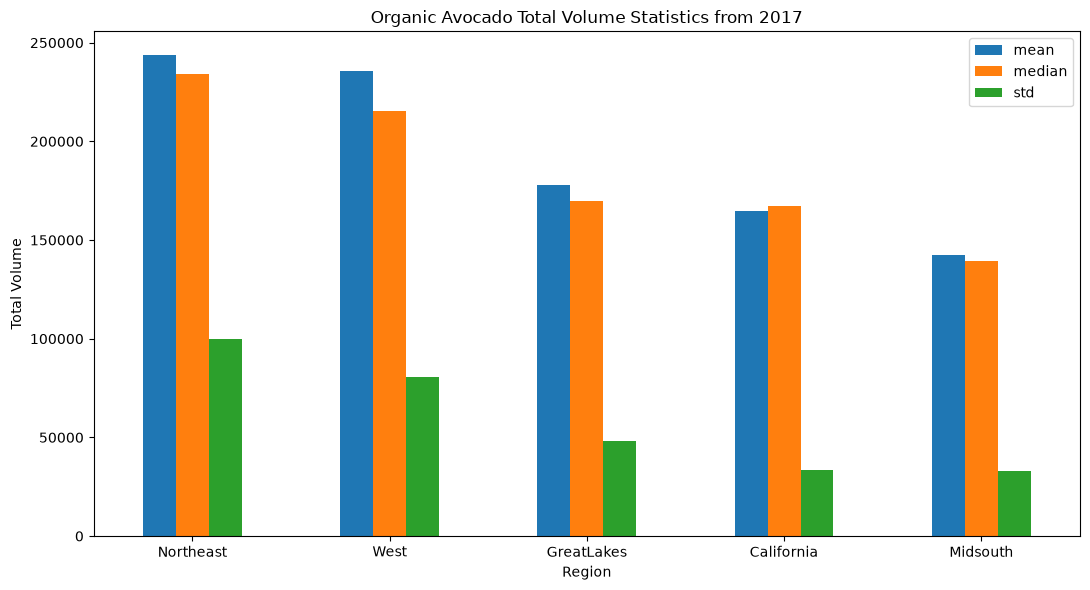

In [4]:
# In my code this one keeps organic avocado records from 2017 onwards and exclude TotalUS
organic_from_2017 = avocado_df[
    (avocado_df["type"] == "organic")
    & (avocado_df["year"] >= 2017)
    & (avocado_df["region"] != "TotalUS")
]

# Now we, find the five regions with the highest overall Total Volume
top_organic_regions = (
    organic_from_2017.groupby("region")["Total Volume"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# It is the right time to calculate the mean, median, and standard deviation for those regions
organic_volume_stats = (
    organic_from_2017[
        organic_from_2017["region"].isin(top_organic_regions)
    ]
    .groupby("region")["Total Volume"]
    .agg(["mean", "median", "std"])
    .loc[top_organic_regions]
)

# Finally we, display the calculated statistics
organic_volume_stats

organic_volume_stats.plot(
    kind="bar",
    figsize=(11, 6),
    title="Organic Avocado Total Volume Statistics from 2017",
    xlabel="Region",
    ylabel="Total Volume",
    rot=0
)

plt.tight_layout()
plt.show()

##### 4. What is the mean and median of AveragePrice for each type of avocado (organic and conventional) in 2018? Be sure to include just the type, MeanPrice, and MedianPrice columns in the results.

In [5]:
# Now we only, keep avocado records from 2018
avocado_2018 = avocado_df[avocado_df["year"] == 2018]

# Calculate the mean and median AveragePrice for each avocado type
price_statistics_2018 = (
    avocado_2018
    .groupby("type", as_index=False)["AveragePrice"]
    .agg(
        MeanPrice="mean",
        MedianPrice="median"
    )
)

# We, display the required columns
price_statistics_2018

,type,MeanPrice,MedianPrice
0,conventional,1.127886,1.14
1,organic,1.567176,1.55


##### 5. Analyze the consistency of sales for Small Bags, Large Bags, XLarge Bags, and Total Bags of the top 3 avocado producing regions (excluding TotalUS) for each type of avocado over time. 

##### *To explain consistency of sales, use the coefficient of variation, which is a statistical measure used to determine the consistency or variability of a data set. It is calculated as the ratio of the standard deviation to the mean, expressed as a percentage. Higher values of the coefficient of variation indicate greater variability or inconsistency in the data, while lower values indicate more consistency in the data.* 

In [6]:
# AS you might already know we need the bag columns required for this analysis
bag_columns = [
    "Small Bags",
    "Large Bags",
    "XLarge Bags",
    "Total Bags"
]

# We, find the top three producing regions based on their total avocado volume
# In my code TotalUS is excluded because it is a national summary, not an individual region
top_3_regions = (
    avocado_df[avocado_df["region"] != "TotalUS"]
    .groupby("region")["Total Volume"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)

print("Top three avocado-producing regions:")
print(list(top_3_regions))

# No we calculate yearly bag sales for each region and avocado type
bag_sales_over_time = (
    avocado_df[avocado_df["region"].isin(top_3_regions)]
    .groupby(["region", "year", "type"])[bag_columns]
    .sum()
)

# Time to calculate the coefficient of variation as a percentage
# CV = standard deviation / mean × 100
cv_results = (
    bag_sales_over_time
    .groupby(["region", "type"])
    .std()
    .div(
        bag_sales_over_time
        .groupby(["region", "type"])
        .mean()
    )
    .mul(100)
    .round(2)
)

# We now rename the columns so the percentage results are clear
cv_results.columns = [
    "Small Bags CV (%)",
    "Large Bags CV (%)",
    "XLarge Bags CV (%)",
    "Total Bags CV (%)"
]

cv_results


Top three avocado-producing regions:
['West', 'California', 'SouthCentral']


Small Bags CV (%)  Large Bags CV (%)  \
region       type                                                 
California   conventional              58.31             110.50   
             organic                   69.08             107.39   
SouthCentral conventional              45.82              66.61   
             organic                   67.55              78.29   
West         conventional              62.86              57.23   
             organic                   77.09              53.10   

                           XLarge Bags CV (%)  Total Bags CV (%)  
region       type                                                 
California   conventional               84.06              59.11  
             organic                      NaN              70.60  
SouthCentral conventional               73.15              49.44  
             organic                      NaN              67.38  
West         conventional               53.69              59.32  
             organic                   115.47              59.61

### C. Learn more
* https://www.statisticshowto.com/probability-and-statistics/how-to-find-a-coefficient-of-variation/